In [1]:
from mpasviewer import scvtmesh
import cartopy.crs as ccrs

In [2]:
path2data = 'sample_data'
mpasd = scvtmesh(grid_file=f'{path2data}/mesh_240km/x1.10242.grid.nc')

In [3]:
mpasd.dataset()

Loaded grid_file dataset: sample_data/mesh_240km/x1.10242.grid.nc


In [4]:
dta = mpasd.load()

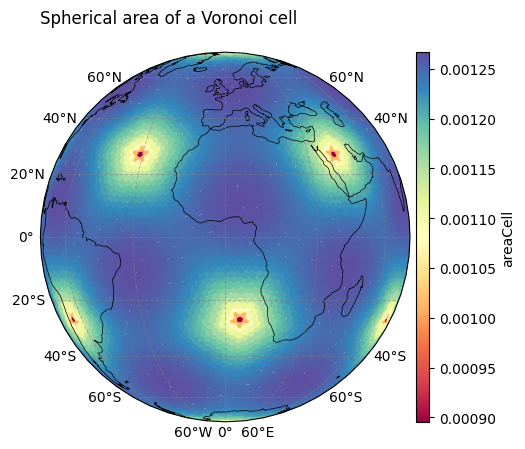

In [5]:
mpasd.show(dta, var_name='areaCell')

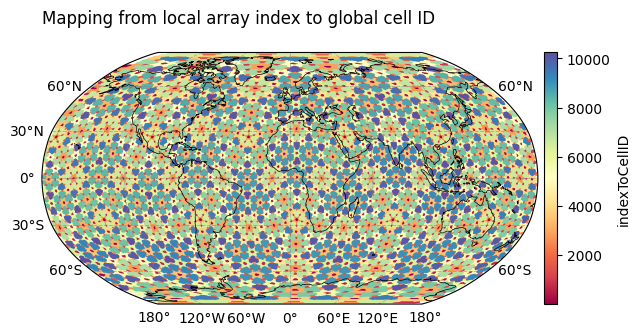

In [6]:
mpasd.show(dta, var_name='indexToCellID', crs=ccrs.Robinson())

In [7]:
from ipywidgets import interact, Dropdown, IntSlider, SelectionSlider
from IPython.display import display, clear_output

In [8]:
variable_names = ['areaCell','indexToCellID',]
variable_dropdown = Dropdown(options=variable_names, description='Variable:')

# Dictionary of available projections
projection_options = {
    "Orthographic": ccrs.Orthographic(central_longitude=-65, central_latitude=50),
    # "Orthographic": ccrs.Orthographic(central_longitude=0, central_latitude=0),
    "PlateCarree": ccrs.PlateCarree(),
    "Mercator": ccrs.Mercator(),
    "Mollweide": ccrs.Mollweide(),
    "Robinson": ccrs.Robinson(),#central_longitude=-95,),
    "SouthPolarStereo": ccrs.SouthPolarStereo(),
    "NorthPolarStereo": ccrs.NorthPolarStereo(),
    "Geostationary":ccrs.Geostationary(),
    "Stereographic":ccrs.Stereographic(),
    "Sinusoidal":ccrs.Sinusoidal(),
    "LambertCylindrical":ccrs.LambertCylindrical(),
    "LambertConformal":ccrs.LambertConformal(),
    "AzimuthalEquidistant":ccrs.AzimuthalEquidistant(),
    "AlbersEqualArea":ccrs.AlbersEqualArea(),
    "RotatedPole":ccrs.RotatedPole(pole_longitude=0.0, pole_latitude=45.0, central_rotated_longitude=0.0),
    "InterruptedGoodeHomolosine":ccrs.InterruptedGoodeHomolosine(),
}

# Dropdown widget to choose projection
proj_dropdown = Dropdown(
    options=list(projection_options.keys()),
    value="Orthographic",
    description="Projection:"
)

def update_plot(variable, proj_name):
    prj = projection_options[proj_name]
    mpasd.show(dta, var_name = variable, crs = prj, figsize = (8, 8))

In [9]:
%%time
# # Create the interactive plot
interact(update_plot, variable=variable_dropdown, proj_name=proj_dropdown)

interactive(children=(Dropdown(description='Variable:', options=('areaCell', 'indexToCellID'), value='areaCell…

CPU times: user 1.49 s, sys: 15.9 ms, total: 1.51 s
Wall time: 1.5 s


<function __main__.update_plot(variable, proj_name)>